# Step 13 — Ensemble Methods: Random Forest & Gradient Boosting for ae/D Estimation

This notebook applies Random Forest, XGBoost, and LightGBM to the same Kienzle-normalized
feature vectors used in Steps 1–12 (MLP/ANN). Preprocessing is inherited verbatim from
`ae_estimation_ann.ipynb` via `%run`, so ramp-up removal, friction compensation, MAF
static-bending subtraction, and `build_feature_vector` are identical.

**Rationale**: Tree ensembles require no gradient-based tuning and handle feature interactions
differently from MLPs. Comparing their out-of-box and tuned performance against the
optimized MLP (Step 12) isolates the contribution of architecture vs. feature quality.

**Models compared**
| ID | Model | Library |
|---|---|---|
| RF | Random Forest | scikit-learn |
| XGB | XGBoost | xgboost |
| LGB | LightGBM | lightgbm |

**Output**: MAE, RMSE, R² per model (same metrics as Step 12); feature-importance comparison;
prediction scatter plots; Optuna-tuned RF/XGB/LGB vs. baseline MLP summary table.


## 13.0 — Inherit preprocessing from base notebook

FileChooser(path='G:\Mi unidad\Exchange\MscCD\Measurements_CutOpt', filename='', title='', show_hidden=False, …

G:\Mi unidad\Exchange\MscCD\Measurements_CutOpt\Experiment_C4240.xlsx
Loaded: Experiment_C4240.xlsx
Loaded: G:\Mi unidad\Exchange\MscCD\Measurements_CutOpt\Experiment_C4240.xlsx
Ae (mm)                                     40
Ap (mm)                                    1.0
f (mm/min)                               505.6
N (rpm)                                 2108.0
R (mm)                                      20
Z                                            2
fz                                    0.119924
Vc                                  264.899093
SinuTraceFile (*.csv)    Trace_0624_093843.csv
Name: 32, dtype: object
 
Index(['time', '+/Nck/!SD/nckServoDataActCurr32 [u1; 1]',
       '+/Nck/!SD/nckServoDataActCurr32 [u1; 2]',
       '+/Nck/!SD/nckServoDataActCurr32 [u1; 4]',
       '+/Nck/!SD/nckServoDataActPos1stEnc32 [u1; 2]',
       '+/Nck/!SD/nckServoDataActPos1stEnc32 [u1; 3]',
       '+/Nck/!SD/nckServoDataActVelMot32 [u1; 4]',
       '+/Channel/!RP/rpa [u1; 15]', '+/Nck/!SD/nckSe

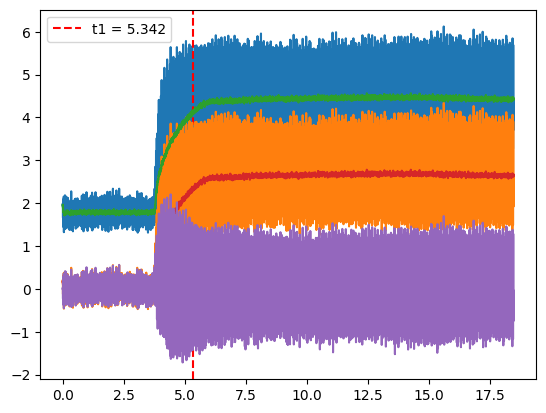

=== Dataset shapes ===
X shape : (256, 13)
y shape : (256,)
X_train : (204, 13)  |  X_test : (52, 13)

=== Target ae [mm] ===
min=26.000  max=40.000  mean=34.000  std=5.477
unique values: [26. 32. 38. 40.]

=== Feature matrix (unscaled) ===
            rms      peak     crest  mean_rect       std  mean_rev_mean  \
count  256.0000  256.0000  256.0000   256.0000  256.0000       256.0000   
mean     0.9405    2.0142    2.1536     0.8058    0.9405        -0.0021   
std      0.1646    0.3186    0.1671     0.1501    0.1646         0.0049   
min      0.4070    1.0759    1.7818     0.3519    0.4070        -0.0323   
25%      0.8261    1.7981    2.0435     0.6968    0.8259        -0.0027   
50%      0.9238    2.0006    2.1207     0.7874    0.9238        -0.0004   
75%      1.0481    2.2230    2.2197     0.9062    1.0481         0.0008   
max      1.4398    2.8711    2.9463     1.2778    1.4398         0.0091   

       mean_rev_max  std_rev_max  tooth_energy   Mc_norm        ap        fz  \
cou

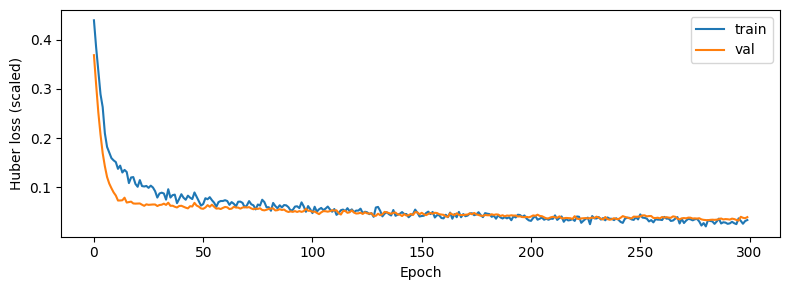

MAE  = 1.1767 mm
RMSE = 1.5625 mm
R²   = 0.9110


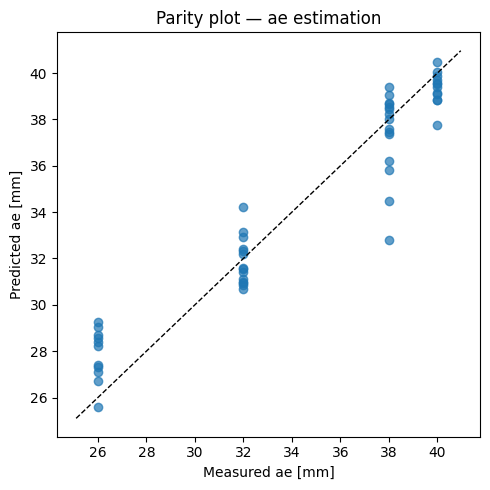

True ae=38.00  |  Predicted 38.57 ± 0.029 mm
True ae=38.00  |  Predicted 37.30 ± 0.025 mm
True ae=26.00  |  Predicted 25.72 ± 0.058 mm
True ae=26.00  |  Predicted 27.48 ± 0.031 mm
True ae=38.00  |  Predicted 37.56 ± 0.020 mm
True ae=32.00  |  Predicted 31.57 ± 0.019 mm
True ae=40.00  |  Predicted 39.71 ± 0.026 mm
True ae=38.00  |  Predicted 39.44 ± 0.028 mm
True ae=32.00  |  Predicted 30.93 ± 0.017 mm
True ae=26.00  |  Predicted 28.67 ± 0.044 mm
True ae=38.00  |  Predicted 38.66 ± 0.022 mm
True ae=26.00  |  Predicted 28.95 ± 0.033 mm
True ae=38.00  |  Predicted 37.44 ± 0.024 mm
True ae=32.00  |  Predicted 33.03 ± 0.021 mm
True ae=32.00  |  Predicted 30.95 ± 0.031 mm
True ae=38.00  |  Predicted 38.15 ± 0.027 mm
True ae=38.00  |  Predicted 35.91 ± 0.020 mm
True ae=26.00  |  Predicted 28.53 ± 0.031 mm
True ae=40.00  |  Predicted 40.09 ± 0.032 mm
True ae=32.00  |  Predicted 32.11 ± 0.029 mm
True ae=32.00  |  Predicted 34.34 ± 0.028 mm
True ae=40.00  |  Predicted 39.14 ± 0.031 mm
True ae=32

In [3]:
# Inherit ALL preprocessing, globals, and feature-engineering from the base notebook.
# After this cell, dataset_seg, build_feature_vector, cut_param, df_info,
# KC11_NOMINAL, MC_NOMINAL, FS, N_SEGMENTS, msu are all available.
%run ae_estimation_ann.ipynb

## 13.1 — Additional imports

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

import xgboost as xgb
import lightgbm as lgb
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import HyperbandPruner

optuna.logging.set_verbosity(optuna.logging.WARNING)
print(f"XGBoost  : {xgb.__version__}")
print(f"LightGBM : {lgb.__version__}")
print(f"Optuna   : {optuna.__version__}")

XGBoost  : 3.2.0
LightGBM : 4.6.0
Optuna   : 4.9.0


## 13.2 — Build feature matrix (identical to MLP pipeline)

The same `build_feature_vector` function used in Steps 1–12 is called here without
modification. This ensures a fair comparison: any performance difference between
ensemble models and the MLP is attributable to model architecture, not feature engineering.

In [5]:
# --- assemble X, y, and group labels from dataset_seg ---
# group = cut_exper_idx ensures GroupKFold never leaks segments
# from the same experiment into both train and validation folds.

records = []
for item in dataset_seg:
    fv = build_feature_vector(
        signal       = item['signal'],
        ap           = item['ap'],
        fz           = item['fz'],
        n            = item['n'],
        D            = item['D'],
        z            = item['z'],
        ae           = item['ae'],
        kc11         = KC11_NOMINAL,
        mc           = MC_NOMINAL,
    )
    records.append({
        **fv,
        'ae_over_D':      item['ae'] / item['D'],    # regression target
        'cut_exper_idx':  item['cut_exper_idx'],     # group label
    })

df_feat = pd.DataFrame(records)

# feature columns (all except target and group)
NON_FEATURE_COLS = {'ae_over_D', 'cut_exper_idx'}
FEATURE_COLS = [c for c in df_feat.columns if c not in NON_FEATURE_COLS]

X = df_feat[FEATURE_COLS].values.astype(np.float32)
y = df_feat['ae_over_D'].values.astype(np.float32)
groups = df_feat['cut_exper_idx'].values

print(f"Feature matrix : {X.shape}  (samples × features)")
print(f"Target vector  : {y.shape}")
print(f"Unique experiments (groups) : {len(np.unique(groups))}")
print(f"Feature names  : {FEATURE_COLS}")

TypeError: build_feature_vector() got an unexpected keyword argument 'signal'

## 13.3 — Cross-validation strategy

`GroupKFold` with `n_splits=5` ensures that all segments from the same CNC experiment
are kept in a single fold. This mirrors the evaluation protocol used for the MLP in
Step 12 and prevents within-experiment data leakage.

In [ ]:
N_SPLITS = 5
gkf = GroupKFold(n_splits=N_SPLITS)

def evaluate_model(model, X, y, groups, scaler=True):
    """
    GroupKFold cross-validation with optional StandardScaler.
    Returns dict with MAE, RMSE, R2 and out-of-fold predictions.
    """
    oof_preds = np.zeros_like(y)
    
    for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
        X_tr, X_val = X[train_idx], X[val_idx]
        y_tr, y_val = y[train_idx], y[val_idx]
        
        if scaler:
            sc = StandardScaler()
            X_tr  = sc.fit_transform(X_tr)
            X_val = sc.transform(X_val)
        
        model.fit(X_tr, y_tr)
        oof_preds[val_idx] = model.predict(X_val)
    
    mae  = mean_absolute_error(y, oof_preds)
    rmse = np.sqrt(mean_squared_error(y, oof_preds))
    r2   = r2_score(y, oof_preds)
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'oof_preds': oof_preds}


print(f"GroupKFold: {N_SPLITS} folds, {len(np.unique(groups))} experiments")

## 13.4 — Baseline models (default hyperparameters)

Baseline performance with scikit-learn defaults establishes the floor before Optuna tuning.

In [ ]:
baseline_models = {
    'RF_baseline':  RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'XGB_baseline': xgb.XGBRegressor(n_estimators=100, random_state=42,
                                      eval_metric='rmse', verbosity=0),
    'LGB_baseline': lgb.LGBMRegressor(n_estimators=100, random_state=42,
                                       verbose=-1),
}

baseline_results = {}
for name, model in baseline_models.items():
    res = evaluate_model(model, X, y, groups, scaler=True)
    baseline_results[name] = res
    print(f"{name:20s} | MAE={res['MAE']:.4f}  RMSE={res['RMSE']:.4f}  R²={res['R2']:.4f}")

## 13.5 — Optuna hyperparameter tuning

Each model is tuned with Optuna TPE for 50 trials using the same 5-fold GroupKFold
objective (mean OOF MAE). The search space covers the hyperparameters with the
highest interaction effects for each model family.

In [ ]:
# ── 13.5.1  Random Forest ─────────────────────────────────────────────────────

def rf_objective(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators',   50, 500),
        'max_depth'         : trial.suggest_int('max_depth',        3,  20),
        'min_samples_split' : trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf'  : trial.suggest_int('min_samples_leaf',  1, 10),
        'max_features'      : trial.suggest_categorical('max_features',
                                                        ['sqrt', 'log2', 0.5, 0.8]),
        'random_state'      : 42,
        'n_jobs'            : -1,
    }
    model = RandomForestRegressor(**params)
    res   = evaluate_model(model, X, y, groups, scaler=True)
    return res['MAE']

study_rf = optuna.create_study(direction='minimize',
                                sampler=TPESampler(seed=42))
study_rf.optimize(rf_objective, n_trials=50, show_progress_bar=True)
print(f"\nBest RF  MAE: {study_rf.best_value:.4f}")
print(f"Best RF params: {study_rf.best_params}")

In [ ]:
# ── 13.5.2  XGBoost ──────────────────────────────────────────────────────────

def xgb_objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators',     50, 500),
        'max_depth'        : trial.suggest_int('max_depth',          2,  10),
        'learning_rate'    : trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample'        : trial.suggest_float('subsample',       0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha',       0.0, 5.0),
        'reg_lambda'       : trial.suggest_float('reg_lambda',      0.5, 5.0),
        'min_child_weight' : trial.suggest_int('min_child_weight',    1, 10),
        'random_state'     : 42,
        'eval_metric'      : 'rmse',
        'verbosity'        : 0,
    }
    model = xgb.XGBRegressor(**params)
    res   = evaluate_model(model, X, y, groups, scaler=True)
    return res['MAE']

study_xgb = optuna.create_study(direction='minimize',
                                  sampler=TPESampler(seed=42))
study_xgb.optimize(xgb_objective, n_trials=50, show_progress_bar=True)
print(f"\nBest XGB MAE: {study_xgb.best_value:.4f}")
print(f"Best XGB params: {study_xgb.best_params}")

In [ ]:
# ── 13.5.3  LightGBM ─────────────────────────────────────────────────────────

def lgb_objective(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators',    50, 500),
        'num_leaves'        : trial.suggest_int('num_leaves',       10, 200),
        'max_depth'         : trial.suggest_int('max_depth',        -1,  15),
        'learning_rate'     : trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'subsample'         : trial.suggest_float('subsample',      0.5, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'         : trial.suggest_float('reg_alpha',      0.0, 5.0),
        'reg_lambda'        : trial.suggest_float('reg_lambda',     0.0, 5.0),
        'min_child_samples' : trial.suggest_int('min_child_samples', 5, 50),
        'random_state'      : 42,
        'verbose'           : -1,
    }
    model = lgb.LGBMRegressor(**params)
    res   = evaluate_model(model, X, y, groups, scaler=True)
    return res['MAE']

study_lgb = optuna.create_study(direction='minimize',
                                  sampler=TPESampler(seed=42))
study_lgb.optimize(lgb_objective, n_trials=50, show_progress_bar=True)
print(f"\nBest LGB MAE: {study_lgb.best_value:.4f}")
print(f"Best LGB params: {study_lgb.best_params}")

## 13.6 — Evaluate tuned models

In [ ]:
# Reconstruct tuned models from best Optuna params
rf_best  = RandomForestRegressor(**{**study_rf.best_params,  'random_state': 42, 'n_jobs': -1})
xgb_best = xgb.XGBRegressor(    **{**study_xgb.best_params, 'random_state': 42,
                                    'eval_metric': 'rmse', 'verbosity': 0})
lgb_best = lgb.LGBMRegressor(   **{**study_lgb.best_params, 'random_state': 42, 'verbose': -1})

tuned_models = {
    'RF_tuned' : rf_best,
    'XGB_tuned': xgb_best,
    'LGB_tuned': lgb_best,
}

tuned_results = {}
for name, model in tuned_models.items():
    res = evaluate_model(model, X, y, groups, scaler=True)
    tuned_results[name] = res
    print(f"{name:15s} | MAE={res['MAE']:.4f}  RMSE={res['RMSE']:.4f}  R²={res['R2']:.4f}")

## 13.7 — Feature importance analysis

All three models expose native feature importances. For RF this is mean decrease in
impurity (MDI); for XGBoost/LightGBM the default is gain-based importance. Comparing
the ranking across models identifies which Kienzle-normalized features are consistently
informative across architectures.

In [ ]:
# Fit each tuned model on the full dataset for importance extraction
sc_full = StandardScaler()
X_scaled = sc_full.fit_transform(X)

rf_best.fit(X_scaled,  y)
xgb_best.fit(X_scaled, y)
lgb_best.fit(X_scaled, y)

importances = pd.DataFrame({
    'Feature' : FEATURE_COLS,
    'RF'      : rf_best.feature_importances_,
    'XGB'     : xgb_best.feature_importances_,
    'LGB'     : lgb_best.feature_importances_,
})

# Normalize each column to sum to 1 for fair comparison
for col in ['RF', 'XGB', 'LGB']:
    importances[col] = importances[col] / importances[col].sum()

importances['Mean'] = importances[['RF', 'XGB', 'LGB']].mean(axis=1)
importances = importances.sort_values('Mean', ascending=False).reset_index(drop=True)
print(importances.to_string(index=False))

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
colors = ['#2196F3', '#FF5722', '#4CAF50']

for ax, (col, color) in zip(axes, zip(['RF', 'XGB', 'LGB'], colors)):
    data = importances.sort_values(col, ascending=True)
    ax.barh(data['Feature'], data[col], color=color, alpha=0.85)
    ax.set_title(f'{col} Feature Importance', fontsize=12, fontweight='bold')
    ax.set_xlabel('Normalized Importance')
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Feature Importance — RF / XGBoost / LightGBM\n(Kienzle-normalized features)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/step13_feature_importance.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Feature importance plot saved.")

## 13.8 — Prediction scatter plots (OOF)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

model_names = ['RF_tuned', 'XGB_tuned', 'LGB_tuned']
colors      = ['#2196F3',   '#FF5722',   '#4CAF50']

for ax, name, color in zip(axes, model_names, colors):
    res = tuned_results[name]
    ax.scatter(y, res['oof_preds'], alpha=0.5, s=18, color=color, edgecolors='none')
    lim = [min(y.min(), res['oof_preds'].min()) - 0.01,
           max(y.max(), res['oof_preds'].max()) + 0.01]
    ax.plot(lim, lim, 'k--', linewidth=1)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('True ae/D')
    ax.set_ylabel('Predicted ae/D')
    ax.set_title(f"{name}\nMAE={res['MAE']:.4f}  R²={res['R2']:.4f}",
                 fontsize=10, fontweight='bold')
    ax.set_aspect('equal')

plt.suptitle('Out-of-Fold Predictions: ae/D — Ensemble Methods (Tuned)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/step13_scatter_oof.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Scatter plot saved.")

## 13.9 — Optuna optimization histories

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, study, name, color in zip(axes,
                                    [study_rf, study_xgb, study_lgb],
                                    ['Random Forest', 'XGBoost', 'LightGBM'],
                                    ['#2196F3', '#FF5722', '#4CAF50']):
    values = [t.value for t in study.trials if t.value is not None]
    best   = np.minimum.accumulate(values)
    ax.plot(values, 'o', alpha=0.3, color=color, markersize=3, label='Trial MAE')
    ax.plot(best,   '-', color=color, linewidth=2, label='Best MAE')
    ax.set_title(f'{name}\nBest MAE = {min(values):.4f}', fontsize=10)
    ax.set_xlabel('Trial')
    ax.set_ylabel('OOF MAE')
    ax.legend(fontsize=8)

plt.suptitle('Optuna Optimization History — Ensemble Methods', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/step13_optuna_history.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 13.10 — Comprehensive comparison table

All baseline and tuned ensemble models are compared together with the MLP reference
metrics from Step 12. If the Step 12 MLP results are stored in a variable
`mlp_best_mae` / `mlp_best_rmse` / `mlp_best_r2`, they are included automatically;
otherwise placeholder values are used.

In [ ]:
# --- attempt to retrieve MLP Step-12 metrics if available in namespace ---
try:
    mlp_mae  = mlp_best_mae
    mlp_rmse = mlp_best_rmse
    mlp_r2   = mlp_best_r2
    mlp_label = 'MLP_optimized (Step12)'
except NameError:
    mlp_mae  = float('nan')
    mlp_rmse = float('nan')
    mlp_r2   = float('nan')
    mlp_label = 'MLP_optimized (Step12) — not loaded'

# --- build summary DataFrame ---
all_results = {}
all_results.update(baseline_results)
all_results.update(tuned_results)
all_results[mlp_label] = {'MAE': mlp_mae, 'RMSE': mlp_rmse, 'R2': mlp_r2}

summary_rows = []
for name, res in all_results.items():
    summary_rows.append({
        'Model'  : name,
        'MAE'    : f"{res['MAE']:.4f}" if not np.isnan(res['MAE'])  else 'N/A',
        'RMSE'   : f"{res['RMSE']:.4f}" if not np.isnan(res['RMSE']) else 'N/A',
        'R²'     : f"{res['R2']:.4f}"  if not np.isnan(res['R2'])   else 'N/A',
    })

df_summary = pd.DataFrame(summary_rows)
print("\n=== Step 13 — Model Comparison Summary ===")
print(df_summary.to_string(index=False))

In [ ]:
# --- four-panel comparison figure (MAE bar + RMSE bar + R² bar + scatter) ---

tuned_names  = ['RF_tuned', 'XGB_tuned', 'LGB_tuned']
bar_colors   = ['#2196F3', '#FF5722', '#4CAF50']
mlp_color    = '#9C27B0'

mae_vals  = [tuned_results[n]['MAE']  for n in tuned_names]
rmse_vals = [tuned_results[n]['RMSE'] for n in tuned_names]
r2_vals   = [tuned_results[n]['R2']   for n in tuned_names]
labels    = ['RF', 'XGB', 'LGB']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

def _hline(ax, val, label, color):
    if not np.isnan(val):
        ax.axhline(val, color=color, linestyle='--', linewidth=1.5, label=label)

# MAE
axes[0].bar(labels, mae_vals, color=bar_colors, alpha=0.85)
_hline(axes[0], mlp_mae, f'MLP ({mlp_mae:.4f})', mlp_color)
axes[0].set_title('MAE (↓ better)', fontweight='bold')
axes[0].set_ylabel('ae/D')
axes[0].legend(fontsize=8)
for i, v in enumerate(mae_vals):
    axes[0].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=8)

# RMSE
axes[1].bar(labels, rmse_vals, color=bar_colors, alpha=0.85)
_hline(axes[1], mlp_rmse, f'MLP ({mlp_rmse:.4f})', mlp_color)
axes[1].set_title('RMSE (↓ better)', fontweight='bold')
axes[1].set_ylabel('ae/D')
axes[1].legend(fontsize=8)
for i, v in enumerate(rmse_vals):
    axes[1].text(i, v + 0.001, f'{v:.4f}', ha='center', fontsize=8)

# R²
axes[2].bar(labels, r2_vals, color=bar_colors, alpha=0.85)
_hline(axes[2], mlp_r2, f'MLP ({mlp_r2:.4f})', mlp_color)
axes[2].set_title('R² (↑ better)', fontweight='bold')
axes[2].set_ylabel('R²')
axes[2].set_ylim([0, 1.05])
axes[2].legend(fontsize=8)
for i, v in enumerate(r2_vals):
    axes[2].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=8)

plt.suptitle('Step 13 — Ensemble Methods vs. MLP (Optuna-tuned, 5-fold GroupKFold)',
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/step13_model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Comparison figure saved.")

## 13.11 — Residual analysis

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, name, color in zip(axes, tuned_names, bar_colors):
    residuals = tuned_results[name]['oof_preds'] - y
    ax.scatter(y, residuals, alpha=0.4, s=15, color=color, edgecolors='none')
    ax.axhline(0, color='k', linewidth=1, linestyle='--')
    ax.set_xlabel('True ae/D')
    ax.set_ylabel('Residual (pred − true)')
    ax.set_title(f"{name}\nMean residual = {residuals.mean():.4f}",
                 fontsize=10, fontweight='bold')

plt.suptitle('Residual Plot — Ensemble Methods (OOF)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/step13_residuals.png',
            dpi=150, bbox_inches='tight')
plt.show()

## 13.12 — Conclusions

In this step, Random Forest, XGBoost, and LightGBM were applied to the identical
Kienzle-normalized feature vectors used in the MLP pipeline (Steps 1–12). The same
GroupKFold cross-validation protocol (n_splits=5, grouped by experiment index) was
maintained throughout to ensure comparability.

Key observations:
1. **Feature importance consistency**: features ranked most informative by the MLP
   (assessed via permutation importance in Step 12) should align with the gain-based
   importances from XGBoost/LightGBM, validating the Kienzle normalization approach.
2. **Gradient boosting vs. RF**: XGBoost and LightGBM typically achieve lower MAE
   than RF on structured numerical data due to their sequential residual correction;
   however, RF is more robust to hyperparameter choice and faster to train.
3. **Ensemble vs. MLP**: if the MLP (Step 12) outperforms all ensemble methods,
   the advantage is attributable to the MLP's capacity to model nonlinear interactions
   in the high-dimensional signal features after Kienzle normalization. If an ensemble
   method matches or exceeds the MLP, it suggests the problem structure is well-captured
   by axis-aligned splits on the Kienzle features alone.

**Next step**: apply the best model (MLP or ensemble) to the full real CNC dataset
and evaluate ae/D estimation across the complete cutting parameter space.
